In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Create a Toy Data sets
X,y=make_moons(n_samples=500,noise=0.25,random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [4]:
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
depths=list(range(1,15))
train_acc=[]
test_acc=[]

for d in depths:
  model=DecisionTreeClassifier(
    max_depth=d,

    random_state=42)

  model.fit(X_train,y_train)

  train_pred=model.predict(X_train)
  test_pred=model.predict(X_test)

  train_acc.append(accuracy_score(y_train,train_pred))
  test_acc.append(accuracy_score(y_test,test_pred))

test_acc

[0.806060606060606,
 0.9030303030303031,
 0.9030303030303031,
 0.9030303030303031,
 0.9151515151515152,
 0.9515151515151515,
 0.9272727272727272,
 0.9515151515151515,
 0.9272727272727272,
 0.9272727272727272,
 0.9272727272727272,
 0.9272727272727272,
 0.9272727272727272,
 0.9272727272727272]

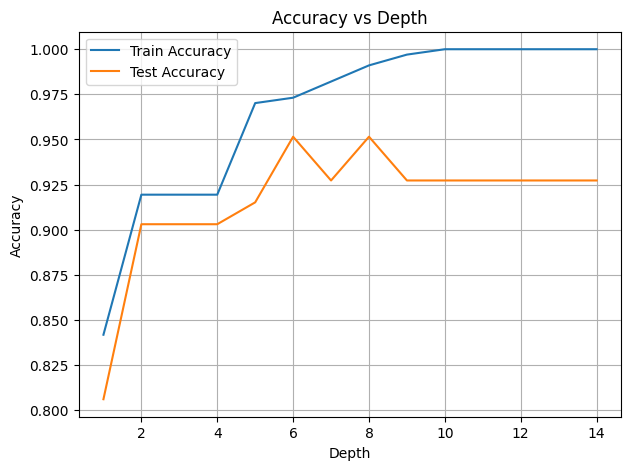

In [5]:
plt.figure(figsize=(7,5))
plt.plot(depths,train_acc,label="Train Accuracy")
plt.plot(depths,test_acc,label="Test Accuracy")
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Depth")
plt.grid(True)
plt.legend()
plt.show()


In [6]:
best_depth=depths[np.argmax(test_acc)]
best_depth

6

Decision Trees - Pruning Techniques

In [7]:
X,y=make_moons(n_samples=600,noise=0.25,random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [8]:
depths=list(range(1,15))
train_acc_pre=[]
test_acc_pre=[]
for d in depths:
  Tree=DecisionTreeClassifier(
    max_depth=d,
    min_samples_leaf=5, # name from min_sample_leaf to min_samples_leaf
    random_state=42)
  Tree.fit(X_train,y_train)
  train_acc_pre.append(accuracy_score(y_train,Tree.predict(X_train)))
  test_acc_pre.append(accuracy_score(y_test,Tree.predict(X_test)))

test_acc_pre

[0.8232323232323232,
 0.898989898989899,
 0.898989898989899,
 0.898989898989899,
 0.9040404040404041,
 0.9141414141414141,
 0.9141414141414141,
 0.9141414141414141,
 0.9141414141414141,
 0.9141414141414141,
 0.9141414141414141,
 0.9141414141414141,
 0.9141414141414141,
 0.9141414141414141]

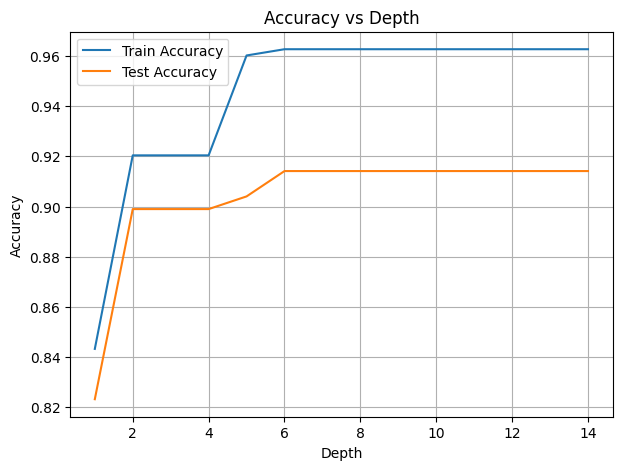

In [9]:
plt.figure(figsize=(7,5))
plt.plot(depths,train_acc_pre,label="Train Accuracy")
plt.plot(depths,test_acc_pre,label="Test Accuracy")
plt.grid(True)
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Depth")
plt.legend()
plt.show()

In [11]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
cpp_alphas=path.ccp_alphas

train_acc_post=[]
test_acc_post=[]

for alpha in cpp_alphas:
  purning_tree=DecisionTreeClassifier(ccp_alpha=alpha,random_state=42)
  purning_tree.fit(X_train,y_train)

  train_acc_post.append(accuracy_score(y_train,purning_tree.predict(X_train)))
  test_acc_post.append(accuracy_score(y_test,purning_tree.predict(X_test)))

test_acc_post

[0.8888888888888888,
 0.8888888888888888,
 0.8939393939393939,
 0.9090909090909091,
 0.9090909090909091,
 0.9090909090909091,
 0.9090909090909091,
 0.9141414141414141,
 0.9191919191919192,
 0.9040404040404041,
 0.9141414141414141,
 0.9141414141414141,
 0.9040404040404041,
 0.9090909090909091,
 0.898989898989899,
 0.8737373737373737,
 0.8232323232323232,
 0.48484848484848486]

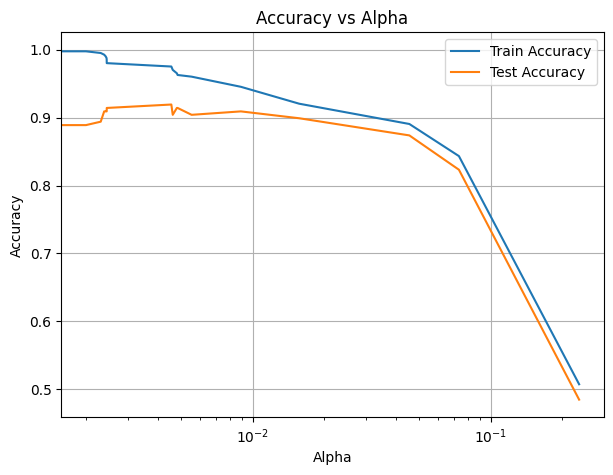

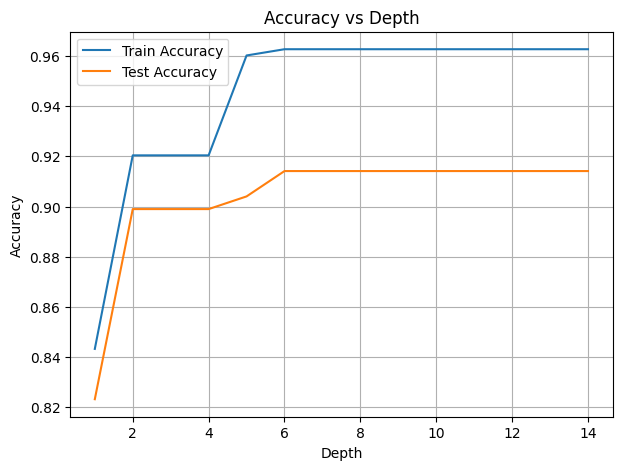

In [14]:
plt.figure(figsize=(7,5))
plt.plot(cpp_alphas,train_acc_post,label="Train Accuracy")
plt.plot(cpp_alphas,test_acc_post,label="Test Accuracy")
plt.grid(True)
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha")
plt.xscale("log")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(depths,train_acc_pre,label="Train Accuracy") # Changed cpp_alphas to depths
plt.plot(depths,test_acc_pre,label="Test Accuracy")   # Changed cpp_alphas to depths
plt.grid(True)
plt.xlabel("Depth")                                  # Changed label to Depth
plt.ylabel("Accuracy")
plt.title("Accuracy vs Depth")                        # Changed title to Accuracy vs Depth
plt.legend()
plt.show()